In [12]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [13]:
df = pd.read_csv("../data/processed/reddit_posts_cleaned.csv")

In [14]:
df.head()

,keyword,title,subreddit,timestamp,post_url,scrape_date,batch_number,source,clean_title,location,skill,role
0,developersindia hiring,How's Infosys for starters 😳,r/IndiaTech,2026-03-10T07:42:32+00:00,https://old.reddit.com/r/IndiaTech/comments/1r...,NaN,NaN,NaN,hows infosys for starters,Unknown,Unknown,Software Engineer
1,developersindia hiring,Who's hiring? - Monthly Megathread - June 2026,r/developersIndia,2026-06-01T04:32:05+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread june 2026,Unknown,Unknown,Software Engineer
2,developersindia hiring,Who's hiring? - Monthly Megathread - February ...,r/developersIndia,2026-02-01T04:32:29+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread february 2026,Unknown,Unknown,Software Engineer
3,developersindia hiring,Who's looking for work? - Monthly Megathread -...,r/developersIndia,2026-06-01T04:30:14+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos looking for work monthly megathread june ...,Unknown,Unknown,Software Engineer
4,developersindia hiring,Who's hiring? - Monthly Megathread - May 2026,r/developersIndia,2026-05-01T04:32:13+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread may 2026,Unknown,Unknown,Software Engineer


In [15]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [16]:
df.dtypes

keyword                      object
title                        object
subreddit                    object
timestamp       datetime64[ns, UTC]
post_url                     object
scrape_date                  object
batch_number                float64
source                       object
clean_title                  object
location                     object
skill                        object
role                         object
dtype: object

In [17]:
df["month"] = df["timestamp"].dt.to_period("M")
df[["timestamp", "month"]].head()

C:\Users\prata\AppData\Local\Temp\ipykernel_30172\1328747890.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["timestamp"].dt.to_period("M")


,timestamp,month
0,2026-03-10 07:42:32+00:00,2026-03
1,2026-06-01 04:32:05+00:00,2026-06
2,2026-02-01 04:32:29+00:00,2026-02
3,2026-06-01 04:30:14+00:00,2026-06
4,2026-05-01 04:32:13+00:00,2026-05


In [18]:
monthly_posts = df.groupby("month").size()

monthly_posts

month
2013-06      1
2014-06      1
2014-08      1
2014-09      1
2014-10      1
          ... 
2026-03    103
2026-04    145
2026-05    250
2026-06    480
2026-07      2
Freq: M, Length: 98, dtype: int64

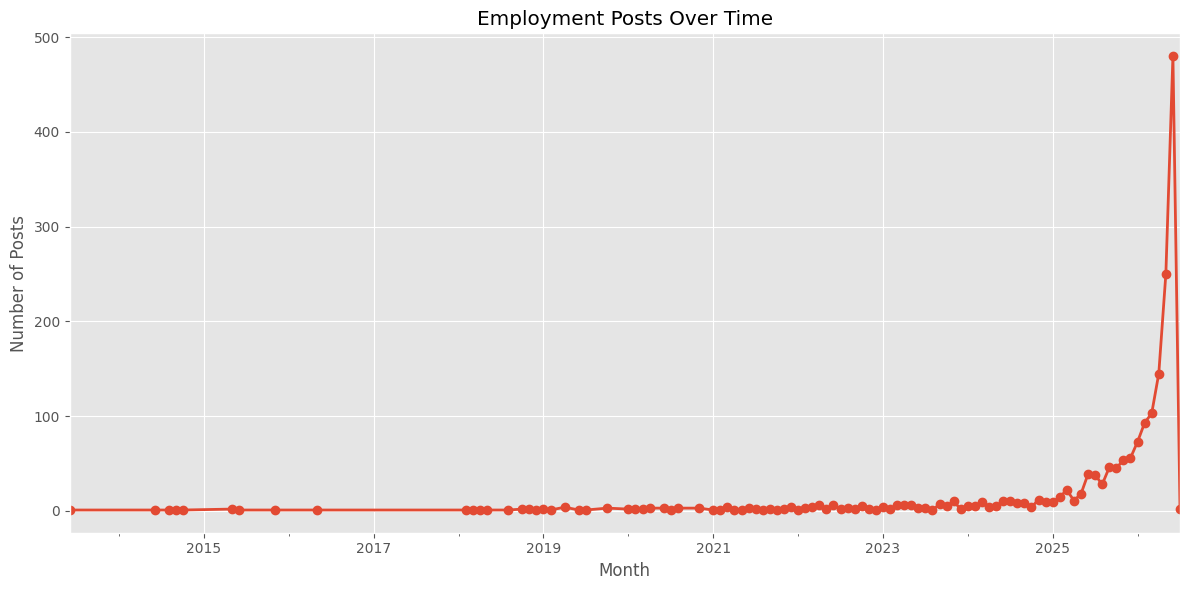

In [19]:
plt.figure(figsize=(12,6))

monthly_posts.plot(
    marker="o",
    linewidth=2
)

plt.title("Employment Posts Over Time")

plt.xlabel("Month")

plt.ylabel("Number of Posts")

plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/figures/monthly_trend.png")

plt.show()

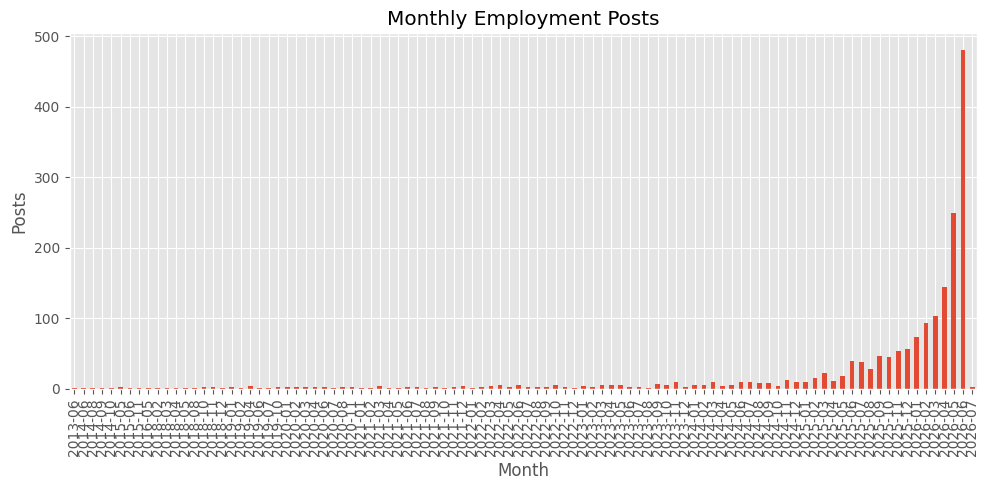

In [20]:
plt.figure(figsize=(10,5))

monthly_posts.plot(
    kind="bar"
)

plt.title("Monthly Employment Posts")

plt.xlabel("Month")

plt.ylabel("Posts")

plt.tight_layout()

plt.savefig("../reports/figures/monthly_bar.png")

plt.show()

In [21]:
monthly_posts.sort_values(ascending=False).head()

month
2026-06    480
2026-05    250
2026-04    145
2026-03    103
2026-02     93
Freq: M, dtype: int64

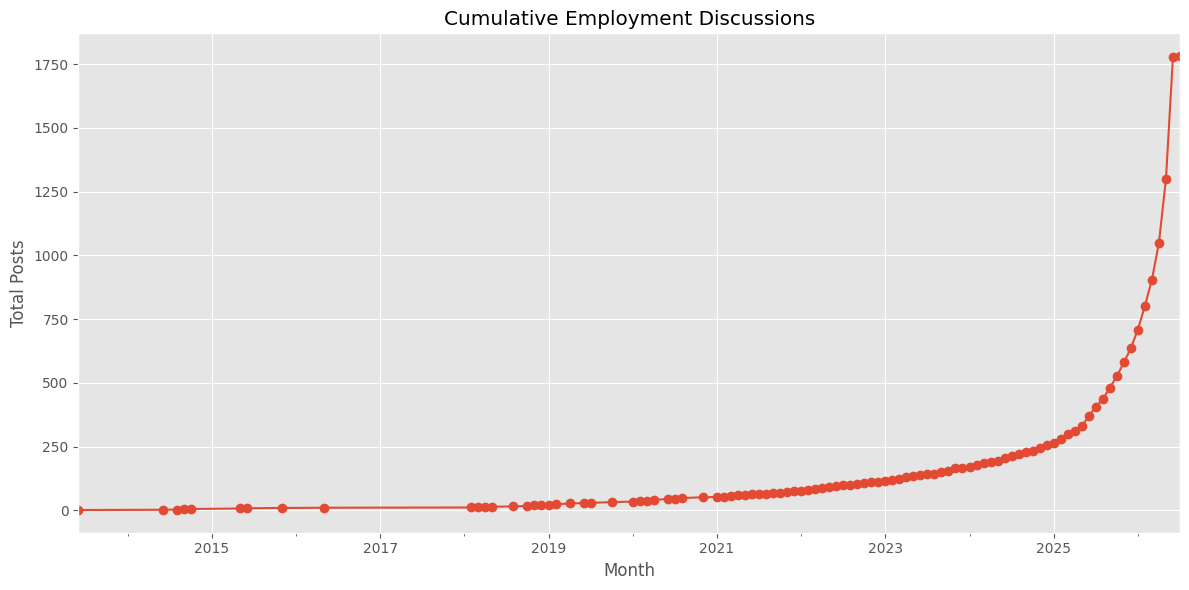

In [22]:
cumulative = monthly_posts.cumsum()

plt.figure(figsize=(12,6))

cumulative.plot(
    marker="o"
)

plt.title("Cumulative Employment Discussions")

plt.xlabel("Month")

plt.ylabel("Total Posts")

plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/figures/cumulative_growth.png")

plt.show()

## Timeline Insights

- Employment discussions increased in the later months of the dataset.
- Recent months show the highest posting activity.
- The trend suggests growing discussion around hiring and employment.
- As more data is collected daily, this timeline will become a useful indicator of hiring trends.